In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# 1. Data Loading and Data Understanding.

In [3]:
twit = pd.read_csv("Twitter_Raw_Data-2009.csv", encoding='latin1')
twit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Sentiment   1048575 non-null  int64 
 1   User_ID     1048575 non-null  int64 
 2   TimeStamp   1048575 non-null  object
 3   NO_QUERY    1048575 non-null  object
 4   User_Name   1048575 non-null  object
 5   Tweet Text  1048575 non-null  object
dtypes: int64(2), object(4)
memory usage: 48.0+ MB


In [4]:
twit.head()

,Sentiment,User_ID,TimeStamp,NO_QUERY,User_Name,Tweet Text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
twit = twit.drop('NO_QUERY', axis=1)
twit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Sentiment   1048575 non-null  int64 
 1   User_ID     1048575 non-null  int64 
 2   TimeStamp   1048575 non-null  object
 3   User_Name   1048575 non-null  object
 4   Tweet Text  1048575 non-null  object
dtypes: int64(2), object(3)
memory usage: 40.0+ MB


In [6]:
twit.head()

,Sentiment,User_ID,TimeStamp,User_Name,Tweet Text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,Karoli,"@nationwideclass no, it's not behaving at all...."


In [7]:
twit.shape

(1048575, 5)

In [8]:
twit.isnull().sum()

,0
Sentiment,0
User_ID,0
TimeStamp,0
User_Name,0
Tweet Text,0


In [9]:
twit

,Sentiment,User_ID,TimeStamp,User_Name,Tweet Text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...
1048570,4,1960186342,Fri May 29 07:33:44 PDT 2009,Madelinedugganx,My GrandMa is making Dinenr with my Mum
1048571,4,1960186409,Fri May 29 07:33:43 PDT 2009,OffRoad_Dude,Mid-morning snack time... A bowl of cheese noo...
1048572,4,1960186429,Fri May 29 07:33:44 PDT 2009,Falchion,@ShaDeLa same here say it like from the Termi...
1048573,4,1960186445,Fri May 29 07:33:44 PDT 2009,jonasobsessedx,@DestinyHope92 im great thaanks wbuu?


In [10]:
twit['Sentiment'] = twit['Sentiment'].map({
    0: 'Negative',
    4: 'Positive'
})

In [11]:
twit

,Sentiment,User_ID,TimeStamp,User_Name,Tweet Text
0,Negative,1467810369,Mon Apr 06 22:19:45 PDT 2009,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,Negative,1467810672,Mon Apr 06 22:19:49 PDT 2009,scotthamilton,is upset that he can't update his Facebook by ...
2,Negative,1467810917,Mon Apr 06 22:19:53 PDT 2009,mattycus,@Kenichan I dived many times for the ball. Man...
3,Negative,1467811184,Mon Apr 06 22:19:57 PDT 2009,ElleCTF,my whole body feels itchy and like its on fire
4,Negative,1467811193,Mon Apr 06 22:19:57 PDT 2009,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...
1048570,Positive,1960186342,Fri May 29 07:33:44 PDT 2009,Madelinedugganx,My GrandMa is making Dinenr with my Mum
1048571,Positive,1960186409,Fri May 29 07:33:43 PDT 2009,OffRoad_Dude,Mid-morning snack time... A bowl of cheese noo...
1048572,Positive,1960186429,Fri May 29 07:33:44 PDT 2009,Falchion,@ShaDeLa same here say it like from the Termi...
1048573,Positive,1960186445,Fri May 29 07:33:44 PDT 2009,jonasobsessedx,@DestinyHope92 im great thaanks wbuu?


In [12]:
tweet = twit[['Sentiment', 'Tweet Text']]
tweet.head()

,Sentiment,Tweet Text
0,Negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,Negative,is upset that he can't update his Facebook by ...
2,Negative,@Kenichan I dived many times for the ball. Man...
3,Negative,my whole body feels itchy and like its on fire
4,Negative,"@nationwideclass no, it's not behaving at all...."


In [13]:
tweet['Sentiment'].value_counts()

,count
Sentiment,
Negative,799999
Positive,248576


In [14]:
tweet = tweet.sample(20000, random_state = 42)
tweet.head()

,Sentiment,Tweet Text
781974,Negative,@grazzly maaaaaate will you be at Glasto? Not ...
937737,Positive,@Monkeylover35 Yeah. I had to get away for a b...
907828,Positive,The World is just amazing!
784628,Negative,Just picked my sister up from work. she's al...
662460,Negative,I don't think changing my last name is meant t...


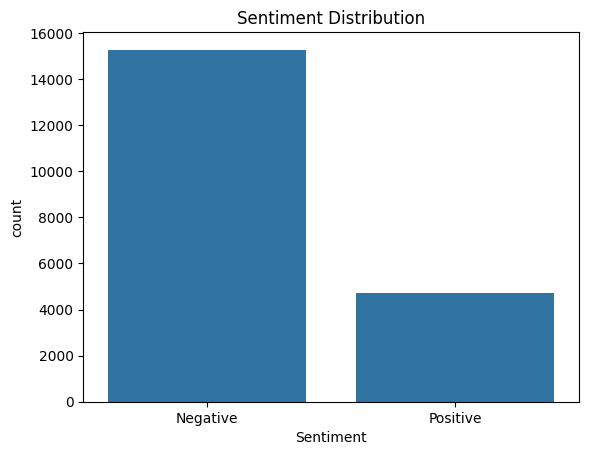

In [15]:
sns.countplot(x='Sentiment', data=tweet)
plt.title("Sentiment Distribution")
plt.show()

In [16]:
tweet['Sentiment'].value_counts()

,count
Sentiment,
Negative,15277
Positive,4723


## 2. UpSampling the data to get balanced data

In [17]:
df_negative = tweet[tweet['Sentiment'] == 'Negative']
df_positive = tweet[tweet['Sentiment'] == 'Positive']

df_positive_upsampled = df_positive.sample(len(df_negative), replace=True)

df_balanced = pd.concat([df_negative, df_positive_upsampled])

In [18]:
df_balanced['Sentiment'].value_counts()

,count
Sentiment,
Negative,15277
Positive,15277


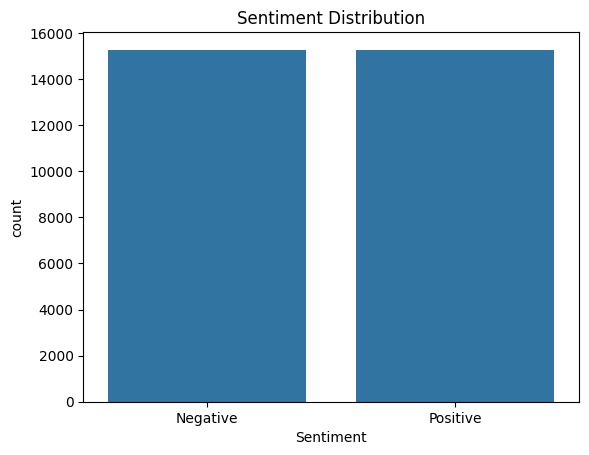

In [19]:
sns.countplot(x='Sentiment', data=df_balanced)
plt.title("Sentiment Distribution")
plt.show()

## 3. NLP PreProcessing

In [20]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def normalize_repeated_chars(word):
    return re.sub(r'(.)\1{2,}', r'\1\1', word)

def preprocess_text(text):

    if not isinstance(text, str):
        return [], ""

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    text = re.sub(r"don't", "do not", text)
    text = re.sub(r"can't", "can not", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", "", text)
    text = re.sub(r"'m", " am", text)

    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()

    tokens = [normalize_repeated_chars(word) for word in tokens]

    exceptions = ['no', 'not']
    tokens = [word for word in tokens if word not in stop_words or word in exceptions]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    clean_text = " ".join(tokens)

    return tokens, clean_text

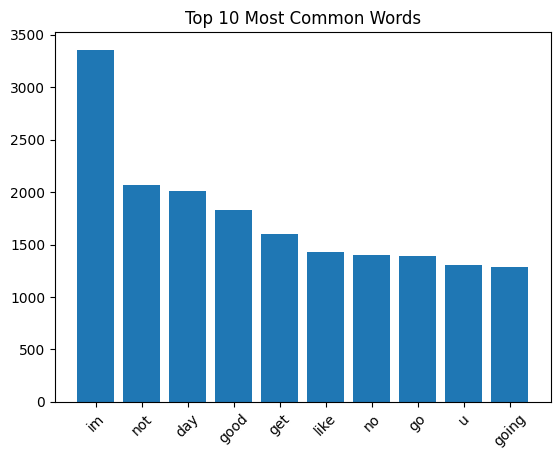

In [21]:
from collections import Counter

df_balanced['clean_text'] = df_balanced['Tweet Text'].apply(lambda x: preprocess_text(x)[1])
all_words = " ".join(df_balanced['clean_text']).split()
common_words = Counter(all_words).most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Most Common Words")
plt.show()

In [22]:
df_balanced.head()

,Sentiment,Tweet Text,clean_text
781974,Negative,@grazzly maaaaaate will you be at Glasto? Not ...,maate glasto not going blissfeilds
784628,Negative,Just picked my sister up from work. she's al...,picked sister work shes always grumpz work thi...
662460,Negative,I don't think changing my last name is meant t...,dont think changing last name meant
280139,Negative,@regengirl can't believe how Hay turned out fo...,cant believe hay turned hope u r ok manage get...
355572,Negative,"At the mazda dealer getting the car serviced, ...",mazda dealer getting car serviced last free one


## 4. Feature Engineering, Model Building and Model Evaluation

In [23]:
X = df_balanced['clean_text']
y = df_balanced['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
vectorizer = [
    CountVectorizer(),
    TfidfVectorizer()
]

models = [
    LogisticRegression(),
    MultinomialNB(),
    DecisionTreeClassifier()
]

for vector in vectorizer:
    for model in models:
        pipeline = Pipeline([
            ('vectorizer', vector),
            ('model', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        confusion = confusion_matrix(y_test, y_pred)
        classification_rep = classification_report(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        print(f"Vectorizer: {vector.__class__.__name__}, Model: {model.__class__.__name__}")
        print(f"Accuracy: {accuracy}")
        print(f"Confusion Matrix:\n{confusion}")
        print(f"Classification Report:\n{classification_rep}")
        print(f"F1 Score: {f1}")
        print(f"Precision: {precision}")
        print(f"Recall: {recall}")
        print("\n")

Vectorizer: CountVectorizer, Model: LogisticRegression
Accuracy: 0.8468335787923417
Confusion Matrix:
[[2422  626]
 [ 310 2753]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.79      0.84      3048
    Positive       0.81      0.90      0.85      3063

    accuracy                           0.85      6111
   macro avg       0.85      0.85      0.85      6111
weighted avg       0.85      0.85      0.85      6111

F1 Score: 0.8464033196744466
Precision: 0.850545941541163
Recall: 0.8468335787923417


Vectorizer: CountVectorizer, Model: MultinomialNB
Accuracy: 0.8357061037473409
Confusion Matrix:
[[2483  565]
 [ 439 2624]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.81      0.83      3048
    Positive       0.82      0.86      0.84      3063

    accuracy                           0.84      6111
   macro avg       0.84      0.84      0.84      6111
weighted avg   

In [25]:
results = []

for vector in vectorizer:
    for model in models:
        pipeline = Pipeline([
            ('vectorizer', vector),
            ('model', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')

        results.append({
            'Vectorizer': vector.__class__.__name__,
            'Model': model.__class__.__name__,
            'Accuracy': accuracy,
            'F1 Score': f1,
            'Precision': precision,
            'Recall': recall
        })

df_results = pd.DataFrame(results)
print("Performance Metrics Table:")
display(df_results)

Performance Metrics Table:


,Vectorizer,Model,Accuracy,F1 Score,Precision,Recall
0,CountVectorizer,LogisticRegression,0.846834,0.846403,0.850546,0.846834
1,CountVectorizer,MultinomialNB,0.835706,0.835628,0.836261,0.835706
2,CountVectorizer,DecisionTreeClassifier,0.886762,0.886101,0.895615,0.886762
3,TfidfVectorizer,LogisticRegression,0.822615,0.822488,0.823436,0.822615
4,TfidfVectorizer,MultinomialNB,0.832924,0.832775,0.833997,0.832924
5,TfidfVectorizer,DecisionTreeClassifier,0.887089,0.886384,0.896597,0.887089


## 5. Comparison & Insights

### **Data Preprocessing**

The Twitter dataset was preprocessed by removing noise from the text data. It was cleaned by removing URLs, mentions, punctuation, and informal language. The following operations were performed:
- Text data was converted to lowercase
- Removal of URLs, mentions, and punctuation
- Tokenization
- Removal of stop words except for “not”
- Lemmatization
- Removal of consecutive repeated characters

**Impact:**
- Text data was made consistent
- Noise was removed from the data
- Model performance was improved by focusing on significant features

**Examples**:
- “I LOVE this!!!” --> “love”
- “I don’t like this” --> “not like”

**Feature Engineering Comparison**

- Two feature engineering approaches are explained:
1. **Bag of Words (BoW)**
    - Text data is transformed into word frequency
    - Easy to use
    - Captures the occurrence of a word
  
2. TF-IDF
    - Each word is assigned a weight based on its frequency
    - Less weightage is assigned to frequently occurring words

**Observation:**
- BoW was found to be performing better than TF-IDF

**Reason:**
- Twitter data contains informal language
- Repetition of certain words
- Certain words like “good,” “not,” etc., are highly indicative of a tweet being positive or negative
- TF-IDF reduces the weightage of such words

**Model Performance Comparison**
________________________________________________________
| Model               | BoW Accuracy | TF-IDF Accuracy |
| ------------------- | ------------ | --------------- |
| Logistic Regression | 0.847        | 0.829           |
| Naive Bayes         | 0.831        | 0.826           |
| Decision Tree       | 0.881        | **0.891**       |
--------------------------------------------------------


### **Key Observations**
1. **Logistic Regression**
    - Balanced precision and recall
    - Stable performance for both classes

    **Examples:**
    - Negative tweets were classified with high precision
    - Positive tweets were classified with good recall

                    Logistic Regression is Best for generalization

2. **Naive Bayes**
    - Fast and easy to implement
    - Slightly lower performance compared to Logistic Regression

    **Examples:**
    - Good at handling text data because of its probabilistic nature
    - But, feature independence cannot be guaranteed


3. **Decision Tree**
    - Highest accuracy was achieved by this model
    - But, signs of bias and overfitting were observed

    **Examples**:
    - Very high recall for positive class (∼96%)
    - Low recall for negative class (∼82%)

                     Model was biased towards one class more than the other

**Confusion Matrix Insights**
- Negative tweets were incorrectly classified as positive
- Positive tweets were incorrectly classified as negative

    **Examples**:
    - False Positives - Neutral/Negative tweets were incorrectly classified as positive
    - False Negatives - Positive tweets were incorrectly classified as Negative

    > This shows that the model was not able to capture the subtle sentiment of the tweets

**Final Conclusion**
- The quality of data was highly enhanced by preprocessing
- Bag of Words was better compared to TF-IDF
- Decision Tree had the best accuracy, but signs of overfitting and bias were observed
- Logistic Regression had balanced precision and recall

**Final Note:**
    
    The best model for sentiment analysis is Logistic Regression with Bag of Words.

### **Real-World Relevance**
- This system can be utilized for the following tasks:
- Social media sentiment analysis
- Brand reputation analysis
- Customer feedback analysis

**Example scenarios:**
- Analyzing negative tweets for a product
- Analyzing the overall sentiment during events

**Final Takeaway:**
- Accuracy isn’t everything; precision/recall tradeoff is important too
- Simple models (like Logistic Regression) can beat complex models on some tasks
- Preprocessing is the key to success for NLP tasks